In [37]:
# Instalación mínima para Google Colab
!pip install -q pandas numpy matplotlib seaborn scikit-learn joblib

In [38]:
#importamos librerias y dependencias y las configuraciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

#opciones para la visualizacion de las tablas
pd.set_option('display.max_columns', None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#configuracion de graficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#gestion de warning
warnings.filterwarnings('ignore')

print("Configuración del entorno\n")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Configuración del entorno

Pandas: 2.2.2
Numpy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [40]:
#descargar una copia del data en local y luego cargarla en el notebook
from google.colab import files
dataset = files.upload()

Saving data_ramon_v04_regresion_devoluciones.csv to data_ramon_v04_regresion_devoluciones.csv


In [41]:
# cargamos el dataset y mostramos 5 filas aleatorias del dataset
try:
    nombre_archivo = list(dataset.keys())[0]
    df = pd.read_csv(nombre_archivo, encoding="cp1252")
    print(f"Archivo {nombre_archivo} cargado exitosamente.")
    display(df.sample(5))
except FileNotFoundError:
    print(f"Error: No se encontró el archivo: {nombre_archivo}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo data_ramon_v04_regresion_devoluciones.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
4609,C562620,22801,ANTIQUE GLASS PEDESTAL BOWL,-1,8/8/2011 12:34,3.75,"13,089.00",United Kingdom,-3.75
4170,C559939,22647,CERAMIC LOVE HEART MONEY BANK,-12,7/14/2011 10:19,1.45,"14,426.00",United Kingdom,-17.40
5479,C567681,22614,PACK OF 12 SPACEBOY TISSUES,-22,9/21/2011 16:24,0.39,"15,433.00",United Kingdom,-8.58
1231,C542426,22418,10 COLOUR SPACEBOY PEN,-24,1/28/2011 9:32,0.85,"14,146.00",United Kingdom,-20.40
5929,C569911,22699,ROSES REGENCY TEACUP AND SAUCER,-1,10/6/2011 16:47,2.95,"16,653.00",United Kingdom,-2.95


,InvoiceDate
860,2011-01-11 15:02:00
6832,2011-11-01 09:41:00
4148,2011-07-12 11:11:00
7135,2011-11-08 16:18:00
1894,2011-03-10 11:15:00


Valores Nat tras parseo: 0



Rango de fechas correcto: 2010 - 2011
Dias unicos encontrados:[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Meses unicosencontrados:[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Años unicos encontrados:[2010, 2011]
Horas unicos encontradas:[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


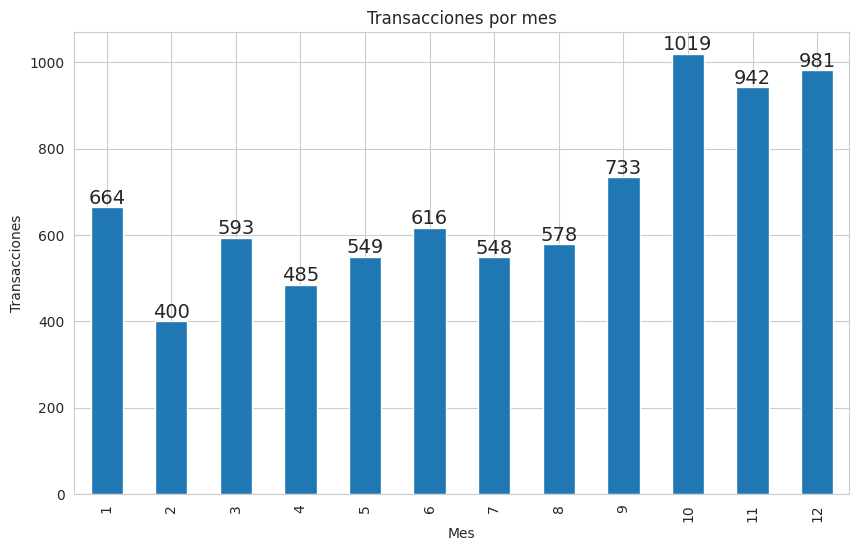

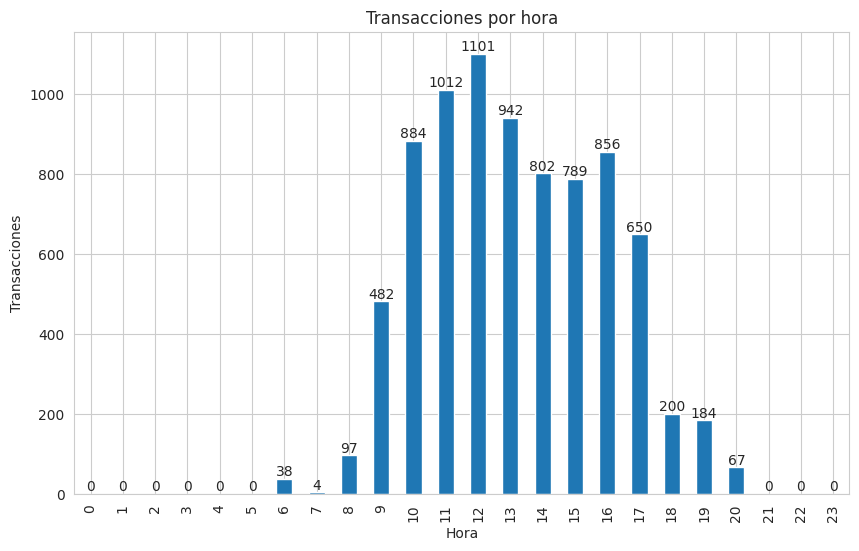

In [42]:
#Creamos las diferentes columnas para invoiceDate(dia,mes,año y hora)
#Nos aseguramos que la columna de InvoiceDate es de tipo date y si no es asi parsearla
if(df['InvoiceDate'].dtype == 'object'):
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

display(df['InvoiceDate'].sample(5))

#Comprobamos que no tengamos datos Nat tras el parseo
print(f"Valores Nat tras parseo: {df['InvoiceDate'].isna().sum()}\n")

#Extraemos cada componente en una columna nueva

df["InvoiceDay"] = df["InvoiceDate"].dt.day
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceHour"] = df["InvoiceDate"].dt.hour

print("\n")

#Comprobamos si las fechas estan en el rango de ventas esperado por el dataset (2010/2011)
if(df['InvoiceYear'].min() == 2010 and df['InvoiceYear'].max() == 2011):
  print(f"Rango de fechas correcto: {df['InvoiceYear'].min()} - {df['InvoiceYear'].max()}")
else:
  print(f"Rango de fechas incorrecto: {df['InvoiceYear'].min()} - {df['InvoiceYear'].max()}")


#Comprobamos si las nuevas columnas tienen sentido
print(f"Dias unicos encontrados:{sorted(df['InvoiceDay'].unique().tolist())}")
print(f"Meses unicosencontrados:{sorted(df['InvoiceMonth'].unique().tolist())}")
print(f"Años unicos encontrados:{sorted(df['InvoiceYear'].unique().tolist())}")
print(f"Horas unicos encontradas:{sorted(df['InvoiceHour'].unique().tolist())}")

#Mostramos numero de transacciones por mes
transaciones_mes = df.groupby('InvoiceMonth').size()
transacciones_mes = transaciones_mes.reindex(range(1,13), fill_value=0)
ax = transaciones_mes.plot(kind='bar')
for m in ax.patches:
    ax.annotate(f'{m.get_height()}',
                (m.get_x() + m.get_width() / 2, m.get_height()),
                ha='center', va='bottom',
                size=14)
plt.xlabel('Mes')
plt.ylabel('Transacciones')
plt.title('Transacciones por mes')
plt.xticks(range(12),range(1,13))
plt.show()


# Reindexamos para incluir todas las horas de 0 a 23, rellenando con 0 las que no existen
# Calculamos los datos primero
ventas_por_hora = df.groupby('InvoiceHour').size()

# Reindexamos para incluir todas las horas de 0 a 23, rellenando con 0 las que no existen
ventas_por_hora = ventas_por_hora.reindex(range(24), fill_value=0)

#Grafico nuemero de ventas por franga horaria
ax = ventas_por_hora.plot(kind='bar')
plt.xlabel('Hora')
plt.ylabel('Transacciones')
plt.title('Transacciones por hora')

# Añadir el número encima de cada barra
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición horizontal: centro de la barra
        bar.get_height(),                     # posición vertical: tope de la barra
        str(int(bar.get_height())),           # el texto: el valor de la barra
        ha='center', va='bottom'              # alineación: centrado y justo encima
    )

plt.show()

# Columna dia de la semana (dayOfWeek)
Añadimos columna de dia de la semana
En un principio barajamos la opcion de añadir una nueva columna llamada "isWeekend" cuyo objetivo era saber si la transaccion se habia realizado en fin de semana o no , pero barajando otras opciones, viendo la naturaleza de los datos y el objetivo de prediccion de ventas diarias , decidimos crear una columna de dia de la semana donde 0 es lunes y 6 es domingo, para los modelos creemos que puede ser mas informativo saber que dia de la semana es que y no tanto el numero como tal del mes , con ello nos dimos cuenta que tener la columna isweekend era redundante.

Sabiendo que son ventas B2B de un mayorista de UK , nos preguntamos si un negocio hace mas pedidios a principios o a finales de mes , para ello deberiamos saber si hay algun patron claro de compra , por lo que saber el dia de la semana tambien puede aportar gran valor a nuestro modelo.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,dayOfWeek
7406,C577351,21671,RED SPOT CERAMIC DRAWER KNOB,-1,2011-11-18 15:37:00,1.45,"17,728.00",United Kingdom,-1.45,18,11,2011,15,4
6426,C570902,22432,WATERING CAN PINK BUNNY,-2,2011-10-13 10:53:00,1.95,"17,724.00",United Kingdom,-3.90,13,10,2011,10,3
4759,C563483,22927,GREEN GIANT GARDEN THERMOMETER,-1,2011-08-16 15:59:00,5.95,"14,175.00",United Kingdom,-5.95,16,8,2011,15,1
581,C539644,22968,ROSE COTTAGE KEEPSAKE BOX,-1,2010-12-20 15:52:00,9.95,"12,471.00",Germany,-9.95,20,12,2010,15,0
2319,C548695,37449,CERAMIC CAKE STAND + HANGING CAKES,-1,2011-04-03 10:08:00,9.95,"17,243.00",United Kingdom,-9.95,3,4,2011,10,6


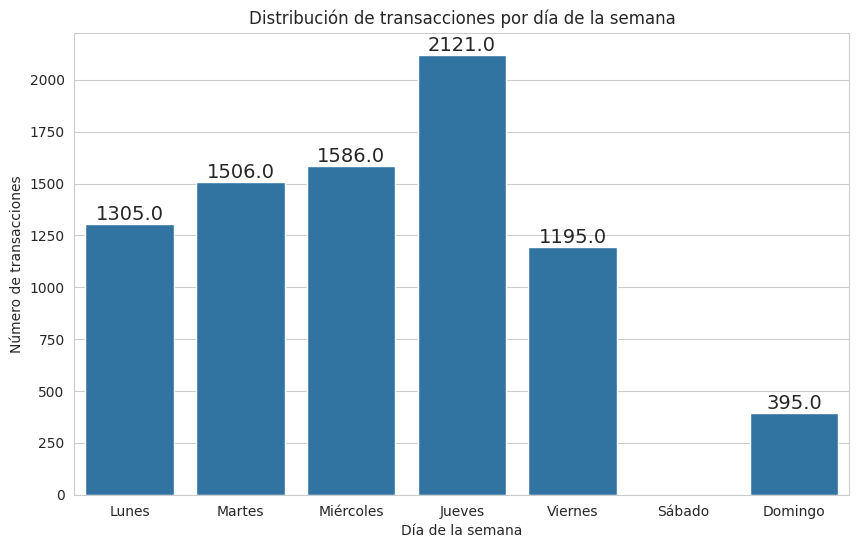

In [43]:
#Añadimos una columna de dia de la semana 0 siendo lunes y 6 siendo domingo
df["dayOfWeek"] = df['InvoiceDate'].dt.weekday
display(df.sample(5))

#Mostramos el numero de transacciones por dia de4 la semana
ax = sns.countplot(data=df, x="dayOfWeek",order=range(7))
for day in ax.patches:
    ax.annotate(f'{day.get_height()}',
                (day.get_x() + day.get_width() / 2, day.get_height()),
                ha='center', va='bottom',
                size=14)
plt.xticks(range(7), ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])
plt.title("Distribución de transacciones por día de la semana")
plt.ylabel("Número de transacciones")
plt.xlabel("Día de la semana")
plt.show()


Con el grafico anterior podemos ver como el sabado no hay transacciones , esto se debe a que es un mercado mayorista , es decir que sus clientes son negocio y no consumidores individuales. Para nuestro modelo esto le indicaria que los sabado no hay ventas.

Otro rasgo importante y que refuerza la idea de añadir el dia de la semana y no la columna isWeekend es que nuestro modelo si hubiera identificado que es fin de semana pero no que sabado y domingo se comportan de manera diferente.

# Sesgo Geográfico
**Se crea la columna de binaria de "isUK" (0 = fuera de Reino Unido, 1 = dentro de Reino Unido) con el objetivo de capturar si una transacción es nacional o internacional.**

Esta variable añade un sesgo geografico a tener en cuenta , ya que la gran mayoria de registros del datset corresponder a transacciones de dentro de UK y una menor cantidad de registros para otros paises.Esto implica que el modelo tendra que aprender patrones hacia el comportamiento dde compra nacional pudiendo generalizar para transacciones internacionales.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,dayOfWeek,isUk
5804,C569128,22729,ALARM CLOCK BAKELIKE ORANGE,-1,2011-09-30 13:34:00,3.75,"15,034.00",United Kingdom,-3.75,30,9,2011,13,4,1
3296,C554870,21175,GIN + TONIC DIET METAL SIGN,-3,2011-05-27 10:57:00,2.55,"15,078.00",United Kingdom,-7.65,27,5,2011,10,4,1
571,C539606,21314,SMALL GLASS HEART TRINKET POT,-2,2010-12-20 14:09:00,1.85,"16,145.00",United Kingdom,-3.70,20,12,2010,14,0,1
782,C540400,21260,FIRST AID TIN,-3,2011-01-07 09:25:00,3.25,"16,150.00",United Kingdom,-9.75,7,1,2011,9,4,1
7955,C580913,22536,MAGIC DRAWING SLATE PURDEY,-120,2011-12-06 13:41:00,0.36,"17,857.00",United Kingdom,-43.20,6,12,2011,13,1,1


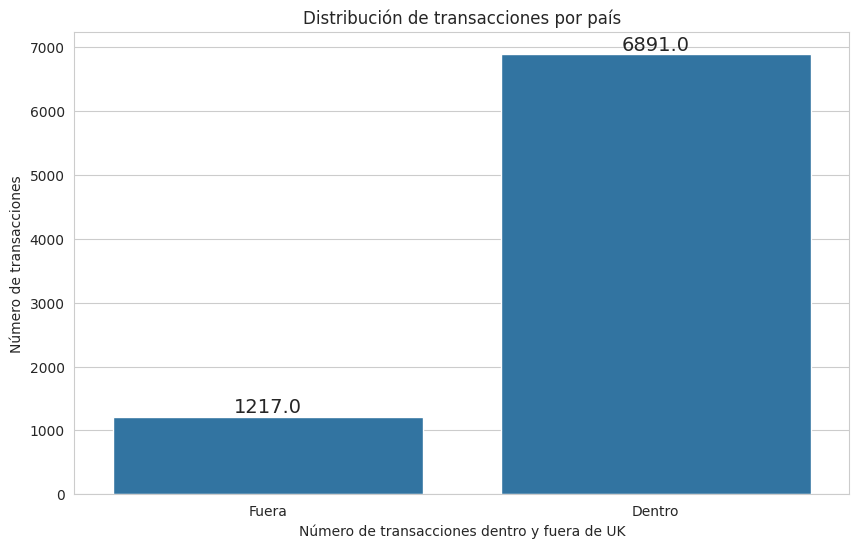

In [44]:
#Creamos la columna binaria  de isUk donde 0 es false y 1 true
df["isUk"] = np.where(df["Country"] == "United Kingdom", 1, 0)
display(df.sample(5))

#Mostramos numero de registros totales dentro y fuera de uk
ax = sns.countplot(data=df, x="isUk")

for bar in ax.patches:
    ax.annotate(f'{bar.get_height()}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom',
                size=14)
plt.xticks([0, 1], ["Fuera", "Dentro"])
plt.title("Distribución de transacciones por país")
plt.ylabel("Número de transacciones")
plt.xlabel("Número de transacciones dentro y fuera de UK")
plt.show()

In [45]:
#Descargar copia para version data_adriansanzllamas_v01
df.to_csv('data_adriansanzllamas_v01_regresion_devoluciones.csv', index=False)
files.download('data_adriansanzllamas_v01_regresion_devoluciones.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>